# CNN Redshift Predictor - Evaluation (Figure 5)

Reproduces Figure 5 from Lizarraga et al. 2024:
- Left: CNN predictions on real test images vs true redshift
- Middle: CNN predictions on generated images vs conditioned redshift
- Right: Mean redshift loss per redshift bin

In [1]:
import os
import numpy as np
import h5py
import torch
import glob
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Input, Concatenate
import tensorflow.keras.backend as K
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## Paths

In [2]:
TEST_HDF5    = '/Users/wen/Desktop/project/archive/5x64x64_testing_with_morphology.hdf5'
GEN_DIR      = '/Users/wen/Desktop/project/lizarraga_2024-main/generated_images'  # download from CSD3
GEN_Z_FILE   = os.path.join(GEN_DIR, 'generated_redshifts.npy')
MODEL_DIR    = '/Users/wen/Desktop/project/lizarraga_2024-main/CNN_Redshift/model_output'
CKPT_BEST    = os.path.join(MODEL_DIR, 'checkpoints/best.weights.h5')

MAG_KEYS = ['g_cmodel_mag', 'r_cmodel_mag', 'i_cmodel_mag', 'z_cmodel_mag', 'y_cmodel_mag']
BATCH_SIZE = 64

## Rebuild and Load Model

In [3]:
def hsc_loss(z_spec, z_photo):
    dz = z_photo - z_spec
    return K.mean(1 - 1.0 / (1.0 + K.square(dz / 0.15)))

def build_model():
    input_cnn = Input(shape=(64, 64, 5), name="image_input")
    x = Conv2D(32,  (3,3), activation="tanh", padding="same")(input_cnn)
    x = tf.keras.layers.MaxPooling2D((2,2))(x)
    x = Conv2D(64,  (3,3), activation="tanh", padding="same")(x)
    x = tf.keras.layers.MaxPooling2D((2,2))(x)
    x = Conv2D(128, (3,3), activation="tanh", padding="same")(x)
    x = tf.keras.layers.MaxPooling2D((2,2))(x)
    x = Conv2D(256, (3,3), activation="tanh", padding="same")(x)
    x = tf.keras.layers.MaxPooling2D((2,2))(x)
    x = Conv2D(256, (3,3), activation="tanh", padding="same")(x)
    x = tf.keras.layers.MaxPooling2D((2,2))(x)
    x = Conv2D(512, (3,3), activation="relu", padding="same")(x)
    x = Conv2D(512, (3,3), activation="relu", padding="same")(x)
    x = Flatten()(x)
    x = Dense(512, activation="tanh")(x)
    x = Dense(128, activation="tanh")(x)
    cnn_out = Dense(32, activation="tanh")(x)
    input_nn = Input(shape=(5,), name="mag_input")
    y = Dense(200, activation="relu")(input_nn)
    y = Dense(200, activation="relu")(y)
    y = Dense(200, activation="relu")(y)
    y = Dense(200, activation="relu")(y)
    y = Dense(200, activation="relu")(y)
    nn_out = Dense(200, activation="relu")(y)
    merged = Concatenate()([cnn_out, nn_out])
    output = Dense(1)(merged)
    return Model(inputs=[input_cnn, input_nn], outputs=output)

model = build_model()
model.compile(optimizer="adam", loss=hsc_loss)
model.load_weights(CKPT_BEST)
print("Model loaded from:", CKPT_BEST)

Model loaded from: /Users/wen/Desktop/project/lizarraga_2024-main/CNN_Redshift/model_output/checkpoints/best.weights.h5


/Users/wen/astro/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:794: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 70 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Predict on Real Test Images (Figure 5 Left)

In [4]:
z_true_list, z_pred_list = [], []

with h5py.File(TEST_HDF5, "r") as f:
    n = f["image"].shape[0]
    for i in tqdm(range(0, n, BATCH_SIZE), desc="Predicting real images"):
        images = f["image"][i:i+BATCH_SIZE].astype("float32")
        images = np.transpose(images, (0, 2, 3, 1))  # channels_last
        mins = images.min(axis=(1,2,3), keepdims=True)
        maxs = images.max(axis=(1,2,3), keepdims=True)
        images = (images - mins) / (maxs - mins + 1e-8)
        mags = np.stack([f[k][i:i+BATCH_SIZE] for k in MAG_KEYS], axis=-1).astype("float32")
        mags = (mags - 20.0) / 5.0
        z_true = f["specz_redshift"][i:i+BATCH_SIZE]
        preds = model.predict([images, mags], verbose=0)
        z_true_list.append(z_true)
        z_pred_list.append(preds.ravel())

z_true = np.concatenate(z_true_list)
z_pred = np.concatenate(z_pred_list)
print(f"Predicted {len(z_true)} real test images")

Predicting real images: 100%|██████████| 640/640 [00:51<00:00, 12.49it/s]

Predicted 40914 real test images


## Predict on Generated Images (Figure 5 Middle)
Download generated images from CSD3 first if not available locally.

In [5]:
z_gen_true_list, z_gen_pred_list = [], []

if os.path.exists(GEN_DIR) and os.path.exists(GEN_Z_FILE):
    pt_files = sorted(glob.glob(os.path.join(GEN_DIR, "generated_image_*.pt")))
    gen_redshifts = np.load(GEN_Z_FILE)
    print(f"Found {len(pt_files)} generated images")

    for i in tqdm(range(0, len(pt_files), BATCH_SIZE), desc="Predicting generated images"):
        batch_files = pt_files[i:i+BATCH_SIZE]
        batch_z     = gen_redshifts[i:i+BATCH_SIZE]
        images = np.stack([torch.load(f, weights_only=False).numpy() for f in batch_files])
        images = np.transpose(images, (0, 2, 3, 1))  # channels_last
        mins = images.min(axis=(1,2,3), keepdims=True)
        maxs = images.max(axis=(1,2,3), keepdims=True)
        images = (images - mins) / (maxs - mins + 1e-8)
        # no mag data for generated images — use zeros as placeholder
        mags = np.zeros((len(images), 5), dtype="float32")
        preds = model.predict([images, mags], verbose=0)
        z_gen_true_list.append(batch_z)
        z_gen_pred_list.append(preds.ravel())

    z_gen_cond = np.concatenate(z_gen_true_list)
    z_gen_pred = np.concatenate(z_gen_pred_list)
    print(f"Predicted {len(z_gen_cond)} generated images")
else:
    print("Generated images not found locally. Download from CSD3 first.")
    print(f"Expected path: {GEN_DIR}")
    z_gen_cond, z_gen_pred = None, None

Generated images not found locally. Download from CSD3 first.
Expected path: /Users/wen/Desktop/project/lizarraga_2024-main/generated_images


## Figure 5

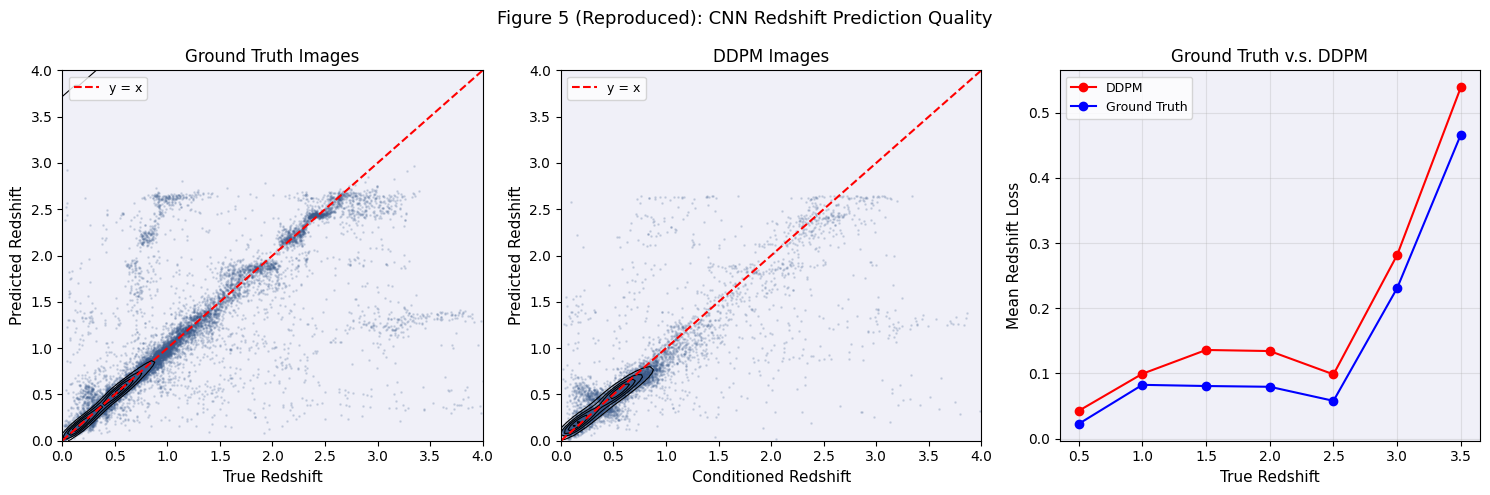

Saved: figure5_reproduce.png


In [23]:
from scipy.stats import gaussian_kde
import matplotlib.colors as mcolors

def plot_scatter_kde(ax, x, y, xlabel, ylabel, title, n_sample=8000):
    ax.set_facecolor('#f0f0f8')
    ax.scatter(x, y, s=1, alpha=0.15, color='#3a5a8a', rasterized=True)
    idx = np.random.choice(len(x), min(n_sample, len(x)), replace=False)
    kde = gaussian_kde(np.vstack([x[idx], y[idx]]), bw_method=0.15)
    xg = np.linspace(0, 4, 100)
    yg = np.linspace(0, 4, 100)
    XX, YY = np.meshgrid(xg, yg)
    Z = kde(np.vstack([XX.ravel(), YY.ravel()])).reshape(XX.shape)
    ax.contour(XX, YY, Z, levels=5, colors='black', linewidths=0.8)
    ax.plot([0, 4], [0, 4], 'r--', linewidth=1.5, label='y = x')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_xlim(0, 4)
    ax.set_ylim(0, 4)
    ax.legend(fontsize=9)

n_panels = 3 if z_gen_cond is not None else 1
fig, axes = plt.subplots(1, n_panels, figsize=(5*n_panels, 5))
if n_panels == 1:
    axes = [axes]

# Left
plot_scatter_kde(axes[0], z_true, z_pred,
                 'True Redshift', 'Predicted Redshift', 'Ground Truth Images')

if z_gen_cond is not None:
    # Middle
    plot_scatter_kde(axes[1], z_gen_cond, z_gen_pred,
                     'Conditioned Redshift', 'Predicted Redshift', 'DDPM Images')

    # Right: mean redshift loss per bin
    bins = np.arange(0.25, 4.1, 0.5)
    bin_centers = bins[:-1] + 0.25
    real_loss, gen_loss = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask_r = (z_true >= lo) & (z_true < hi)
        mask_g = (z_gen_cond >= lo) & (z_gen_cond < hi)
        real_loss.append(np.mean(np.abs(z_pred[mask_r] - z_true[mask_r]) / (1 + z_true[mask_r])) if mask_r.sum() > 0 else np.nan)
        gen_loss.append(np.mean(np.abs(z_gen_pred[mask_g] - z_gen_cond[mask_g]) / (1 + z_gen_cond[mask_g])) if mask_g.sum() > 0 else np.nan)

    axes[2].set_facecolor('#f0f0f8')
    axes[2].plot(bin_centers, gen_loss,  'ro-', label='DDPM')
    axes[2].plot(bin_centers, real_loss, 'bo-', label='Ground Truth')
    axes[2].set_xlabel('True Redshift', fontsize=11)
    axes[2].set_ylabel(r'Mean Redshift Loss', fontsize=11)
    axes[2].set_title('Ground Truth v.s. DDPM', fontsize=12)
    axes[2].legend(fontsize=9)
    axes[2].grid(True, alpha=0.3)

plt.suptitle('Figure 5 (Reproduced): CNN Redshift Prediction Quality', fontsize=13)
plt.tight_layout()
plt.savefig('/Users/wen/Desktop/project/lizarraga_2024-main/Metrics/figure5_reproduce.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figure5_reproduce.png')

In [9]:
print("z_true range:", z_true.min(), "-", z_true.max())
print("z_pred range:", z_pred.min(), "-", z_pred.max())
print("z_pred mean:", z_pred.mean())


z_true range: 0.0108099999 - 3.999717
z_pred range: -0.053195983 - 2.9710531
z_pred mean: 0.58363265


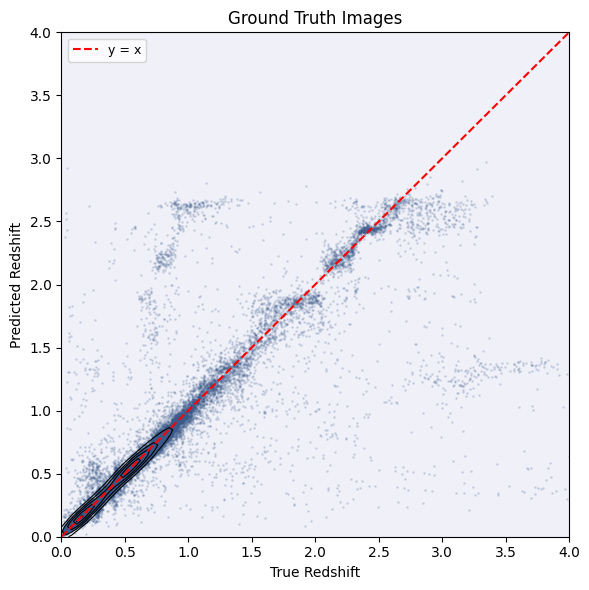

In [13]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_facecolor('#f0f0f8')

# 散点（全部，小点半透明）
ax.scatter(z_true, z_pred, s=1, alpha=0.15, color='#3a5a8a', rasterized=True)

# KDE 等高线（用子集计算，够用）
idx = np.random.choice(len(z_true), 8000, replace=False)
xy = np.vstack([z_true[idx], z_pred[idx]])
kde = gaussian_kde(xy, bw_method=0.15)

# 计算网格上的密度
xg = np.linspace(0, 4, 100)
yg = np.linspace(0, 4, 100)
XX, YY = np.meshgrid(xg, yg)
Z = kde(np.vstack([XX.ravel(), YY.ravel()])).reshape(XX.shape)

ax.contour(XX, YY, Z, levels=5, colors='black', linewidths=0.8)

ax.plot([0, 4], [0, 4], 'r--', linewidth=1.5, label='y = x')
ax.set_xlabel('True Redshift')
ax.set_ylabel('Predicted Redshift')
ax.set_title('Ground Truth Images')
ax.set_xlim(0, 4)
ax.set_ylim(0, 4)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()



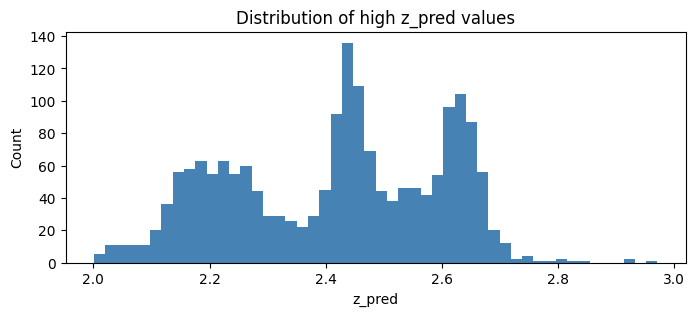

99th percentile of z_pred: 2.595
Max z_pred: 2.971
Mode approx (most common bin): 2.416


In [15]:
# 看高端预测值的分布
high_pred = z_pred[z_pred > 2.0]
plt.figure(figsize=(8, 3))
plt.hist(high_pred, bins=50, color='steelblue')
plt.xlabel('z_pred')
plt.ylabel('Count')
plt.title('Distribution of high z_pred values')
plt.show()

# 统计数字
print(f"99th percentile of z_pred: {np.percentile(z_pred, 99):.3f}")
print(f"Max z_pred: {z_pred.max():.3f}")
print(f"Mode approx (most common bin): {high_pred.mean():.3f}")


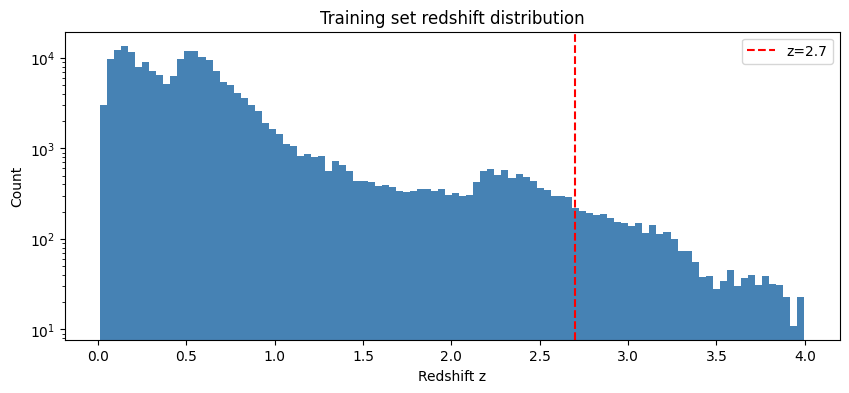

Total: 204573
z < 1.5: 189844 (92.8%)
z > 2.7: 2904 (1.4%)


In [14]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

with h5py.File('/Users/wen/Desktop/project/archive/5x64x64_training_with_morphology.hdf5', 'r') as f:
    z = f['specz_redshift'][:]

plt.figure(figsize=(10, 4))
plt.hist(z, bins=100, color='steelblue')
plt.xlabel('Redshift z')
plt.ylabel('Count')
plt.title('Training set redshift distribution')
plt.yscale('log')
plt.axvline(2.7, color='red', linestyle='--', label='z=2.7')
plt.legend()
plt.show()

print(f"Total: {len(z)}")
print(f"z < 1.5: {(z<1.5).sum()} ({(z<1.5).mean()*100:.1f}%)")
print(f"z > 2.7: {(z>2.7).sum()} ({(z>2.7).mean()*100:.1f}%)")


Why there is a line around 2.6-2.7:

1. 20 epochs in our implementation, high redshift has small proportion, so in backpropagate the average (mini batch will take the mean of all sample) make the effect smaller


2. 为什么 z>2.7 梯度消失：

HSC loss 的梯度公式：
dL/dz_pred ∝ dz / (1 + (dz/0.15)²)²
当误差 dz 很大时，分母增长是 dz⁴，分子只是 dz，结果梯度以 1/dz³ 速度衰减：

dz	梯度大小
0.1（预测接近）	~22
0.5	~0.5
0.8（差 0.8）	~0.04
z_true=3.5 的星系，模型预测 2.7，dz=0.8，梯度只有 0.04，约为准确预测时的 1/500——这就是 HSC loss 的设计：对大误差"宽容"（减小异常值的影响），但副作用是大误差区域几乎学不动。

loss = |z_hat - z| / (1 + z)


In [16]:
import os, glob
GEN_DIR = '/Users/wen/Desktop/project/lizarraga_2024-main/generated_images'
pt_files = sorted(glob.glob(os.path.join(GEN_DIR, 'generated_image_*.pt')))
print(f"Found {len(pt_files)} generated images")
print(f"Redshifts file exists: {os.path.exists(os.path.join(GEN_DIR, 'generated_redshifts.npy'))}")


Found 10000 generated images
Redshifts file exists: True


## Comparison

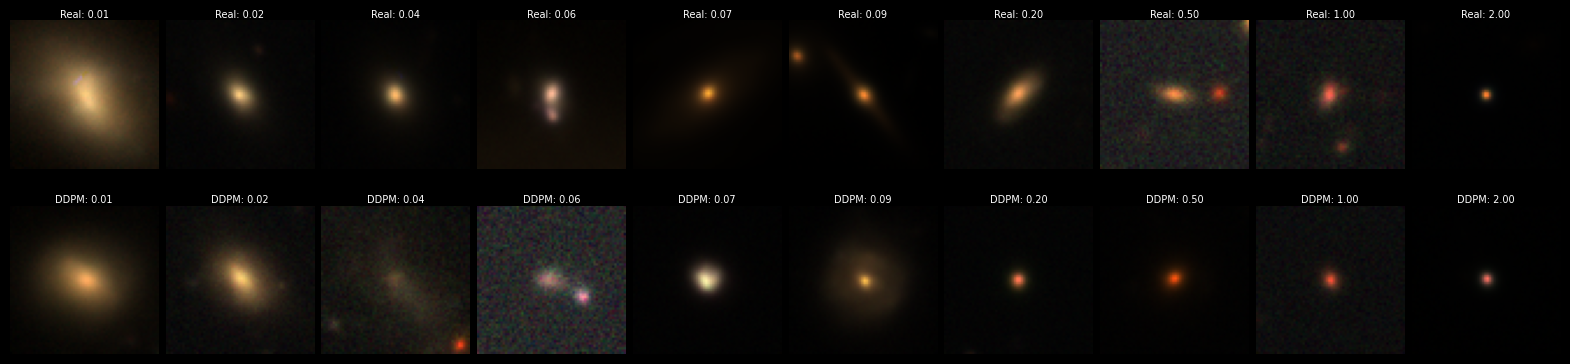

Saved: figure6_reproduce.png


In [25]:
import h5py
import torch
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

TEST_HDF5 = '/Users/wen/Desktop/project/archive/5x64x64_testing_with_morphology.hdf5'
GEN_DIR   = '/Users/wen/Desktop/project/lizarraga_2024-main/generated_images'
GEN_Z     = np.load(os.path.join(GEN_DIR, 'generated_redshifts.npy'))

# Target redshifts (match paper)
target_z = [0.01, 0.02, 0.04, 0.06, 0.07, 0.09, 0.20, 0.50, 1.00, 2.00]

def to_rgb(image):
    """Convert 5-channel image to RGB using g,r,i channels"""
    if isinstance(image, torch.Tensor):
        image = image.numpy()
    rgb = image[[2, 1, 0]]  # i→R, r→G, g→B

    rgb = np.transpose(rgb, (1, 2, 0))
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    return rgb

# Find real images closest to each target z
with h5py.File(TEST_HDF5, 'r') as f:
    all_z = f['specz_redshift'][:]
    real_images = []
    real_z_found = []
    for tz in target_z:
        idx = np.argmin(np.abs(all_z - tz))
        img = f['image'][idx]
        real_images.append(to_rgb(torch.tensor(img)))
        real_z_found.append(all_z[idx])

# Find generated images closest to each target z
pt_files = sorted(glob.glob(os.path.join(GEN_DIR, 'generated_image_*.pt')))
gen_images = []
gen_z_found = []
for tz in target_z:
    idx = np.argmin(np.abs(GEN_Z - tz))
    img = torch.load(pt_files[idx], weights_only=False)
    gen_images.append(to_rgb(img))
    gen_z_found.append(GEN_Z[idx])

# Plot
n = len(target_z)
fig, axes = plt.subplots(2, n, figsize=(2*n, 4.5))
fig.patch.set_facecolor('black')

for i in range(n):
    # Top row: Real
    axes[0, i].imshow(real_images[i])
    axes[0, i].set_title(f'Real: {real_z_found[i]:.2f}', 
                          color='white', fontsize=7, pad=2)
    axes[0, i].axis('off')
    
    # Bottom row: DDPM
    axes[1, i].imshow(gen_images[i])
    axes[1, i].set_title(f'DDPM: {gen_z_found[i]:.2f}', 
                          color='white', fontsize=7, pad=2)
    axes[1, i].axis('off')

plt.subplots_adjust(wspace=0.05, hspace=0.15)
plt.savefig('/Users/wen/Desktop/project/lizarraga_2024-main/Metrics/figure6_reproduce.png',
            dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print("Saved: figure6_reproduce.png")
